In [1]:
! pip install pandas numpy requests beautifulsoup4 openpyxl matplotlib seaborn reportlab lxml selenium os

ERROR: Could not find a version that satisfies the requirement os (from versions: none)

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for os


In [2]:
## Import file

import requests
from bs4 import BeautifulSoup
import pandas as pd
import seaborn as sns
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import time
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.common.exceptions import NoSuchElementException

In [3]:
# Launch Chrome
driver = webdriver.Chrome()

url = "https://www.crossword.in/collections/young-adult-romance"
driver.get(url)

# Wait for page load
time.sleep(8)

# Get all products
products = driver.find_elements(By.CLASS_NAME, "product-item-wrapper")

print(f"Total Products Found: {len(products)}")

books = []

for i, product in enumerate(products, start=1):

    # Book Name
    try:
        book_name = product.get_attribute("title")

        if not book_name:
            book_name = product.find_element(
                By.TAG_NAME,
                "a"
            ).get_attribute("title")

    except:
        book_name = "N/A"

    # Author Name
    try:
        author = product.find_element(
            By.CSS_SELECTOR,
            ".product-item-author"
        ).text.strip()

    except:
        try:
            author = product.find_element(
                By.CSS_SELECTOR,
                ".product-author"
            ).text.strip()

        except:
            author = "N/A"

    # Selling Price
    try:
        selling_price = product.find_element(
            By.CLASS_NAME,
            "product-item-original-price"
        ).text.strip()

        selling_price = selling_price.replace("₹", "")

    except:
        selling_price = ""

    # Original Price
    try:
        original_price = product.find_element(
            By.CLASS_NAME,
            "product-item-compare-price"
        ).text.strip()

        original_price = original_price.replace("₹", "")

    except:
        original_price = ""

    # Discount
    try:
        discount = product.find_element(
            By.CLASS_NAME,
            "discount-percent"
        ).text.strip()

    except:
        discount = ""

    books.append([
        i,
        book_name,
        author,
        original_price,
        selling_price,
        discount
    ])

# Create DataFrame
df = pd.DataFrame(
    books,
    columns=[
        "Sl No",
        "Book Name",
        "Author Name",
        "Original Price",
        "Selling Price",
        "Discount"
    ]
)

# Create folder if it doesn't exist
os.makedirs("Data Store", exist_ok=True)

# Save Excel file
df.to_excel(
    "Data Store/Young_Adult_Romance_Books.xlsx",
    index=False
)

print(df.head())

driver.quit()

print("Excel file created successfully!")

Total Products Found: 24
   Sl No                Book Name    Author Name Original Price Selling Price  \
0      1   Better Than The Movies   Lynn Painter          \n499         \n375   
1      2  Nothing Like The Movies   Lynn Painter          \n499         \n375   
2      3           Betting On You   Lynn Painter          \n499         \n375   
3      4             Fake Skating   Lynn Painter          \n499         \n375   
4      5             Check & Mate  Ali Hazelwood          \n599         \n450   

    Discount  
0  ₹ 124 Off  
1  ₹ 124 Off  
2  ₹ 124 Off  
3  ₹ 124 Off  
4  ₹ 149 Off  
Excel file created successfully!


In [5]:
df = pd.read_excel("Data Store/Young_Adult_Romance_Books.xlsx")

print(df.info())
print(df.isnull().sum())

df.drop_duplicates(inplace=True)

df.fillna("Unknown", inplace=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Sl No           24 non-null     int64 
 1   Book Name       24 non-null     object
 2   Author Name     24 non-null     object
 3   Original Price  24 non-null     int64 
 4   Selling Price   24 non-null     int64 
 5   Discount        24 non-null     object
dtypes: int64(3), object(3)
memory usage: 1.3+ KB
None
Sl No             0
Book Name         0
Author Name       0
Original Price    0
Selling Price     0
Discount          0
dtype: int64


In [6]:
df["Original Price"] = df["Original Price"].astype(str).str.replace("₹", "", regex=False)
df["Selling Price"] = df["Selling Price"].astype(str).str.replace("₹", "", regex=False)

df["Original Price"] = pd.to_numeric(df["Original Price"], errors="coerce")
df["Selling Price"] = pd.to_numeric(df["Selling Price"], errors="coerce")

! Analysis

In [7]:
# Total Books
print("Total Books:", len(df))

# Total Original Price
print("Total Original Price:", df["Original Price"].sum())

# Total Selling Price
print("Total Selling Price:", df["Selling Price"].sum())

# Total Profit
Total_Profit = (df["Original Price"] - df["Selling Price"]).sum()

print("Total Profit", Total_Profit)

# Average Original Price
print("Average Original Price:", df["Original Price"].mean())

# Average Selling Price
print("Average Selling Price:", df["Selling Price"].mean())

# Highest Original Price
print(df.loc[df["Original Price"].idxmax()])

# Highest Selling Price
print(df.loc[df["Selling Price"].idxmax()])

Total Books: 24
Total Original Price: 13431
Total Selling Price: 10420
Total Profit 3011
Average Original Price: 559.625
Average Selling Price: 434.1666666666667
Sl No                                                        8
Book Name         Better Than The Movies (Collector's Edition)
Author Name                                       Lynn Painter
Original Price                                             799
Selling Price                                              640
Discount                                             ₹ 159 Off
Name: 7, dtype: object
Sl No                             18
Book Name         The Midnight Train
Author Name                Matt Haig
Original Price                   799
Selling Price                    720
Discount                    ₹ 79 Off
Name: 17, dtype: object


In [11]:
top10 = df.sort_values(
    by="Selling Price",
    ascending=False
).head(10)

print(top10)

    Sl No                                         Book Name       Author Name  \
17     18                                The Midnight Train         Matt Haig   
21     22                                    Land of Dreams          EL James   
20     21                                    Land of Ghosts          EL James   
7       8      Better Than The Movies (Collector's Edition)      Lynn Painter   
13     14                                 First And Forever      Lynn Painter   
6       7                                  The Night Circus  Erin Morgenstern   
18     19  Six Times We Almost Kissed (And One Time We Did)       Tess Sharpe   
22     23                   As Long As The Lemon Trees Grow     Zoulfa Katouh   
4       5                                      Check & Mate     Ali Hazelwood   
16     17                            If Only I Had Told Her      Laura Nowlin   

    Original Price  Selling Price   Discount  
17             799            720   ₹ 79 Off  
21            

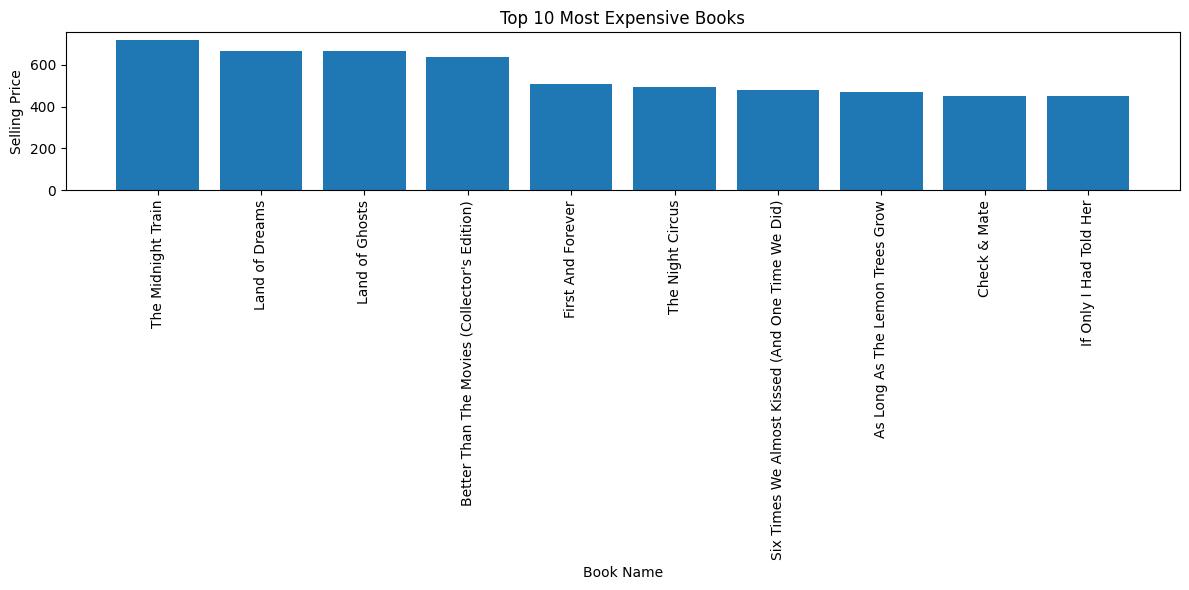

In [12]:
top10 = df.sort_values(
    by="Selling Price",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10["Book Name"],
    top10["Selling Price"]
)

plt.xticks(rotation=90)
plt.title("Top 10 Most Expensive Books")
plt.xlabel("Book Name")
plt.ylabel("Selling Price")

plt.tight_layout()

plt.savefig("Image/Top Expensive Books.png", dpi=300)
plt.show()

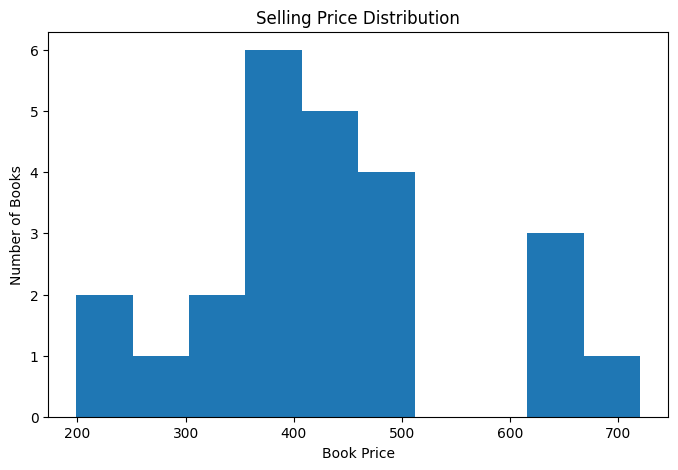

In [13]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Selling Price"],
    bins=10
)

plt.title("Selling Price Distribution")
plt.xlabel("Book Price")
plt.ylabel("Number of Books")

plt.savefig("Image/Selling Price Distribution.png", dpi=300)
plt.show()

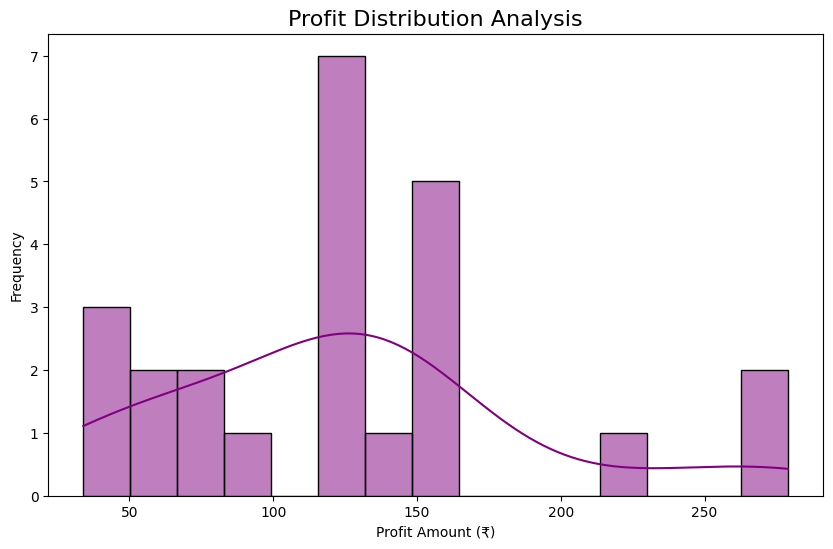

In [14]:
df["Profit"] = df["Original Price"] - df["Selling Price"]

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Profit",
    bins=15,
    kde=True,
    color="purple"
)

plt.title("Profit Distribution Analysis", fontsize=16)
plt.xlabel("Profit Amount (₹)")
plt.ylabel("Frequency")

plt.savefig("Image/Total_Profit.png", dpi=300)
plt.show()

Save to as PDF File

In [15]:
from reportlab.platypus import (
    SimpleDocTemplate,
    Paragraph,
    Spacer,
    Image,
    PageBreak
)

from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib.enums import TA_CENTER, TA_JUSTIFY

# =========================
# Analysis Values
# =========================

total_books = len(df)

total_original_price = df["Original Price"].sum()

total_selling_price = df["Selling Price"].sum()

total_profit = (df["Original Price"] - df["Selling Price"]).sum()

avg_original_price = round(
    df["Original Price"].mean(), 2
)

avg_selling_price = round(
    df["Selling Price"].mean(), 2
)

top_book = df.loc[
    df["Selling Price"].idxmax(),
    "Book Name"
]

top_discount_book = df.loc[
    (df["Original Price"] - df["Selling Price"]).idxmax(),
    "Book Name"
]

# =========================
# PDF
# =========================

pdf = SimpleDocTemplate(
    "Young_Adult_Romance_Report.pdf"
)

styles = getSampleStyleSheet()

styles["BodyText"].alignment = TA_JUSTIFY

content = []

# =========================
# Title
# =========================

content.append(
    Paragraph(
        "Young Adult Romance Report Data Analysis",
        styles["Title"]
    )
)

content.append(Spacer(1,20))

# =========================
# Executive Summary
# =========================

content.append(
    Paragraph(
        "Summary",
        styles["Heading1"]
    )
)

summary = f"""
This report presents a detailed analysis of Young Adult Romance books collected from the 
Crossword website using Selenium Web Scraping. The dataset contains book titles, authors, 
original prices, selling prices, and discount information. <br/><br/>
The objective of this analysis is to understand pricing patterns, discount strategies, and 
book value trends. Python libraries such as Pandas, Matplotlib, Seaborn, and ReportLab were 
used for data cleaning, visualization, and automated report generation.
"""

content.append(
    Paragraph(summary, styles["BodyText"])
)

content.append(Spacer(1,15))

# =========================
# Key Insights
# =========================

content.append(
    Paragraph(
        "Key Business Questions & Answers",
        styles["Heading1"]
    )
)

questions = f"""
• Total Books Available : {total_books}<br/><br/>
• Total Original Price Value : ₹{total_original_price}<br/><br/>
• Total Selling Price Value : ₹{total_selling_price}<br/><br/>
• Total Discount / Profit : ₹{total_profit}<br/><br/>
• Average Original Price : ₹{avg_original_price}<br/><br/>
• Average Selling Price : ₹{avg_selling_price}<br/><br/>
• Highest Selling Book : {top_book}<br/><br/>
• Highest Discount Book : {top_discount_book}<br/>
"""

content.append(
    Paragraph(
        questions,
        styles["BodyText"]
    )
)

content.append(PageBreak())

# =========================
# Visualization 1
# =========================

content.append(
    Paragraph(
        "Top 10 Most Expensive Books",
        styles["Heading1"]
    )
)

content.append(
    Image(
        "Image/Top Expensive Books.png",
        width=450,
        height=250
    )
)

content.append(
    Paragraph(
        """
        The chart highlights the top-selling premium books available in the Young Adult 
        Romance category. These books contribute significantly to the overall revenue and 
        represent the highest-valued products in the collection.
        """,
        styles["BodyText"]
    )
)

content.append(PageBreak())

# =========================
# Visualization 2
# =========================

content.append(
    Paragraph(
        "Selling Price Distribution",
        styles["Heading1"]
    )
)

content.append(
    Image(
        "Image/Selling Price Distribution.png",
        width=450,
        height=250
    )
)

content.append(
    Paragraph(
        """
        The distribution chart shows how book prices are spread across different price 
        ranges. Most books are concentrated within a specific price segment, indicating 
        a focused pricing strategy.
        """,
        styles["BodyText"]
    )
)

content.append(PageBreak())

# =========================
# Visualization 3
# =========================

content.append(
    Paragraph(
        "Profit / Discount Distribution",
        styles["Heading1"]
    )
)

content.append(
    Image(
        "Image/Total_Profit.png",
        width=450,
        height=250
    )
)

content.append(
    Paragraph(
        """
        The profit distribution analysis demonstrates the discount patterns offered on books. 
        A majority of products fall within a moderate discount range, while a few books receive 
        larger promotional discounts.
        """,
        styles["BodyText"]
    )
)

content.append(PageBreak())

# =========================
# Conclusion
# =========================

content.append(
    Paragraph(
        "Conclusion",
        styles["Heading1"]
    )
)

conclusion = """
The analysis reveals that the Young Adult Romance category contains a diverse range of 
books with varying price points and discount levels. Several premium books contribute 
significantly to the overall value of the collection, while discounts play an important 
role in improving customer affordability and purchase decisions.
"""

content.append(
    Paragraph(
        conclusion,
        styles["BodyText"]
    )
)

content.append(Spacer(1,15))

# =========================
# Recommendations
# =========================

content.append(
    Paragraph(
        "Business Recommendations",
        styles["Heading1"]
    )
)

recommendation = """
• Focus promotional campaigns on high-discount books to increase sales volume.<br/><br/>
• Monitor premium-priced books as they contribute significantly to total revenue.<br/><br/>
• Maintain competitive pricing within the most common customer price range.<br/><br/>
• Introduce targeted offers on slow-moving books to improve inventory turnover.<br/><br/>
• Analyze author popularity to optimize future stock and marketing decisions.<br/>
"""

content.append(
    Paragraph(
        recommendation,
        styles["BodyText"]
    )
)

# =========================
# Build PDF
# =========================

pdf.build(content)

print("Young_Adult_Romance_Report.pdf Created Successfully")

Young_Adult_Romance_Report.pdf Created Successfully
